# 02 — Seattle Commute Mode and Travel Time Trends

This notebook analyzes travel-to-work patterns for workers whose place of work is in
the Seattle-area POWPUMA (workplace super-PUMA), using ACS PUMS microdata downloaded
in notebook 01.

**Key outputs:**
1. Time trends in the **number** of Seattle-area workers by commute mode
2. Time trends in the **fraction** of Seattle-area workers by commute mode
3. Time trends in **mean travel time** by commute mode

All estimates use person weights (PWGTP) and standard errors use the 80 replicate
weights (PWGTP1–PWGTP80) with the successive difference replication method.

**Caveats:**
- **2020 is experimental** — lower response rates due to COVID-19 mean higher uncertainty
- **PUMA geography changed twice**: 2000-based → 2010-based (at 2011/2012) and
  2010-based → 2020-based (at 2021/2022). The set of workers captured as "Seattle"
  differs slightly across vintages.

In [1]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
import seaborn as sns

DATA_DIR = os.path.abspath(os.path.join('..', 'data'))
RAW_DIR = os.path.join(DATA_DIR, 'raw', 'acs_pums')
DERIVED_DIR = os.path.join(DATA_DIR, 'derived')

YEARS_2000_PUMA = list(range(2005, 2012))    # 2000-based PUMAs
YEARS_2010_PUMA = list(range(2012, 2022))     # 2010-based PUMAs (includes 2020)
YEARS_2020_PUMA = [2022, 2023]                # 2020-based PUMAs
ALL_YEARS = YEARS_2000_PUMA + YEARS_2010_PUMA + YEARS_2020_PUMA

REP_COLS = [f'PWGTP{i}' for i in range(1, 81)]

sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (12, 6)

print(f'Years: {ALL_YEARS}')
print(f'2000-based PUMA years: {YEARS_2000_PUMA}')
print(f'2010-based PUMA years: {YEARS_2010_PUMA}')
print(f'2020-based PUMA years: {YEARS_2020_PUMA}')

Years: [2005, 2006, 2007, 2008, 2009, 2010, 2011, 2012, 2013, 2014, 2015, 2016, 2017, 2018, 2019, 2020, 2021, 2022, 2023]
2000-based PUMA years: [2005, 2006, 2007, 2008, 2009, 2010, 2011]
2010-based PUMA years: [2012, 2013, 2014, 2015, 2016, 2017, 2018, 2019, 2020, 2021]
2020-based PUMA years: [2022, 2023]


## Identify Seattle workplace PUMAs

POWPUMA (place-of-work PUMA) uses **super-PUMA** codes — coarser geographic units
than residential PUMAs. We identify the super-PUMA codes that cover Seattle
for all three PUMA vintages (2000-based, 2010-based, 2020-based).

In [2]:
# Load 2010 PUMA names from gazetteer to show residential PUMAs
gaz_path = os.path.join(RAW_DIR, '2010_Gaz_PUMAs_national.txt')
gaz = pd.read_csv(gaz_path, sep='\t', dtype=str, encoding='latin-1')
gaz.columns = gaz.columns.str.strip()
wa_2010 = gaz[gaz['USPS'] == 'WA'].copy()
wa_2010['puma'] = wa_2010['GEOID'].str[2:].astype(int)

seattle_2010 = wa_2010[wa_2010['NAME'].str.contains('Seattle', case=False, na=False)]
print('2010-based Seattle residential PUMAs (11601–11605):')
for _, row in seattle_2010.iterrows():
    print(f"  {row['puma']:>5d}  {row['NAME']}")

print()
print('POWPUMA uses super-PUMA codes (coarser than residential PUMAs).')
print('Seattle workplace super-PUMAs by vintage:')
print('  2000-based (2005–2011): POWPUMA 2000')
print('  2010-based (2012–2021): POWPUMA 11600')
print('  2020-based (2022+):     POWPUMA 23300')

2010-based Seattle residential PUMAs (11601–11605):
  11605  Seattle City (West)--Duwamish & Beacon Hill PUMA
  11602  Seattle City (Northeast) PUMA
  11601  Seattle City (Northwest) PUMA
  11603  Seattle City (Downtown)--Queen Anne & Magnolia PUMA
  11604  Seattle City (Southeast)--Capitol Hill PUMA

POWPUMA uses super-PUMA codes (coarser than residential PUMAs).
Seattle workplace super-PUMAs by vintage:
  2000-based (2005–2011): POWPUMA 2000
  2010-based (2012–2021): POWPUMA 11600
  2020-based (2022+):     POWPUMA 23300


In [3]:
# ------------------------------------------------------------------
# Define Seattle POWPUMA (workplace super-PUMA) sets
# ------------------------------------------------------------------
# POWPUMA codes are coarser than residential PUMAs. Each super-PUMA
# aggregates multiple residential PUMAs into one workplace area.
#
# 2000-based (2005–2011 ACS):
#   POWPUMA 2000 covers Seattle City residential PUMAs (2001–2009)
#
# 2010-based (2012–2021 ACS):
#   POWPUMA 11600 covers Seattle residential PUMAs (11601–11605)
#
# 2020-based (2022+ ACS):
#   POWPUMA 23300 covers Seattle residential PUMAs (23312–23318)

SEATTLE_POWPUMA_2000 = {2000}
SEATTLE_POWPUMA_2010 = {11600}
SEATTLE_POWPUMA_2020 = {23300}

print(f'2000-based Seattle POWPUMA: {sorted(SEATTLE_POWPUMA_2000)}')
print(f'2010-based Seattle POWPUMA: {sorted(SEATTLE_POWPUMA_2010)}')
print(f'2020-based Seattle POWPUMA: {sorted(SEATTLE_POWPUMA_2020)}')


def get_seattle_powpumas(year):
    """Return the set of POWPUMA codes for Seattle given the ACS year."""
    if year <= 2011:
        return SEATTLE_POWPUMA_2000
    elif year <= 2021:
        return SEATTLE_POWPUMA_2010
    else:
        return SEATTLE_POWPUMA_2020

2000-based Seattle POWPUMA: [2000]
2010-based Seattle POWPUMA: [11600]
2020-based Seattle POWPUMA: [23300]


## Harmonize commute mode variable

The ACS PUMS commute mode variable changed from **JWTR** (through 2018) to
**JWTRNS** (2019+), with different code values. We harmonize both into a
common set of mode categories. Vehicle occupancy (JWRIP / DRIVESP)
distinguishes drove-alone from carpool.

In [4]:
# Pre-2019 JWTR codes → raw label
JWTR_MAP = {
    1: 'Car, truck, or van',
    2: 'Bus or trolley bus',
    3: 'Streetcar or trolley car',
    4: 'Subway or elevated',
    5: 'Railroad',
    6: 'Ferryboat',
    7: 'Taxicab',
    8: 'Motorcycle',
    9: 'Bicycle',
    10: 'Walked',
    11: 'Worked from home',
    12: 'Other method',
}

# Post-2019 JWTRNS codes → raw label
# Note: code 11 = Worked from home (verified by COVID-era spike to ~34%)
#        code 12 = Other method (consistently ~0.7%)
JWTRNS_MAP = {
    1: 'Car, truck, or van',
    2: 'Bus',
    3: 'Subway or elevated rail',
    4: 'Long-distance train or commuter rail',
    5: 'Light rail, streetcar, or trolley',
    6: 'Ferryboat',
    7: 'Taxicab',
    8: 'Motorcycle',
    9: 'Bicycle',
    10: 'Walked',
    11: 'Worked from home',
    12: 'Other method',
}

# Harmonized categories
def raw_to_harmonized(raw_label, is_carpool=False):
    """Map a raw Census mode label to a harmonized category."""
    if raw_label is None or pd.isna(raw_label):
        return None
    s = str(raw_label)
    if 'Car' in s or 'car' in s or 'Van' in s or 'van' in s or 'truck' in s:
        return 'Carpooled' if is_carpool else 'Drove alone'
    if 'Bus' in s or 'bus' in s:
        return 'Bus'
    if any(kw in s for kw in ('Subway', 'Railroad', 'rail', 'Light rail', 'Streetcar', 'trolley')):
        return 'Rail/streetcar'
    if 'Ferry' in s or 'ferry' in s:
        return 'Ferry'
    if 'Bicycle' in s or 'bicycle' in s:
        return 'Bicycle'
    if 'Walked' in s or 'walked' in s:
        return 'Walked'
    if 'home' in s.lower():
        return 'Worked from home'
    return 'Other'


def harmonize_modes(df):
    """Add 'mode' column with harmonized commute mode categories."""
    cols = set(df.columns)

    # Determine commute mode variable
    if 'JWTRNS' in cols:
        jwtr_col = 'JWTRNS'
        code_map = JWTRNS_MAP
    elif 'JWTR' in cols:
        jwtr_col = 'JWTR'
        code_map = JWTR_MAP
    else:
        raise ValueError(f'No commute mode variable found. Columns: {sorted(cols)}')

    # Determine carpool variable
    if 'DRIVESP' in cols:
        rip_col = 'DRIVESP'
    elif 'JWRIP' in cols:
        rip_col = 'JWRIP'
    else:
        rip_col = None

    # Map code → raw label
    df['mode_raw'] = df[jwtr_col].map(code_map)

    # Detect carpool vs drove alone
    is_car = df['mode_raw'].str.contains('Car|car|Van|van|truck', case=False, na=False)
    is_carpool = pd.Series(False, index=df.index)
    if rip_col:
        is_carpool = is_car & df[rip_col].notna() & (df[rip_col] > 1)

    df['mode'] = df['mode_raw'].apply(lambda x: raw_to_harmonized(x, is_carpool=False))
    df.loc[is_carpool, 'mode'] = 'Carpooled'

    return df


print('Mode harmonization functions defined.')

Mode harmonization functions defined.


## Standard error computation with replicate weights

ACS PUMS uses successive difference replication with 80 replicate weights.

$$\text{SE}(\hat{\theta}) = \sqrt{\frac{4}{80} \sum_{r=1}^{80} (\hat{\theta}_r - \hat{\theta})^2}$$

In [5]:
def replicate_se(est_full, est_reps):
    """Standard error via successive difference replication."""
    est_reps = np.asarray(est_reps, dtype=float)
    return np.sqrt((4.0 / 80.0) * np.nansum((est_reps - est_full) ** 2))


def weighted_total_with_se(weights, rep_weights_df):
    """Weighted total and SE."""
    total = weights.sum()
    reps = [rep_weights_df[c].sum() for c in REP_COLS if c in rep_weights_df.columns]
    se = replicate_se(total, reps)
    return total, se


def weighted_proportion_with_se(indicator, weights, rep_weights_df):
    """Weighted proportion and SE."""
    indicator = np.asarray(indicator, dtype=float)
    w = np.asarray(weights, dtype=float)
    p = np.sum(indicator * w) / np.sum(w)

    p_reps = []
    for c in REP_COLS:
        if c not in rep_weights_df.columns:
            continue
        wr = np.asarray(rep_weights_df[c], dtype=float)
        denom = np.sum(wr)
        p_reps.append(np.sum(indicator * wr) / denom if denom > 0 else np.nan)

    se = replicate_se(p, p_reps)
    return p, se


def weighted_mean_with_se(values, weights, rep_weights_df):
    """Weighted mean and SE."""
    mask = np.isfinite(values) & np.isfinite(weights)
    v = np.asarray(values[mask], dtype=float)
    w = np.asarray(weights[mask], dtype=float)
    mean_full = np.average(v, weights=w)

    rw = rep_weights_df.loc[mask]
    mean_reps = []
    for c in REP_COLS:
        if c not in rw.columns:
            continue
        wr = np.asarray(rw[c], dtype=float)
        if wr.sum() > 0:
            mean_reps.append(np.average(v, weights=wr))
        else:
            mean_reps.append(np.nan)

    se = replicate_se(mean_full, mean_reps)
    return mean_full, se


print('SE functions defined.')

SE functions defined.


## Load and filter data

Load all years, filter to workers whose place of work is in Seattle PUMAs,
and harmonize commute modes.

In [6]:
frames = []
for year in ALL_YEARS:
    f = os.path.join(DERIVED_DIR, f'acs_pums_wa_commute_{year}.parquet')
    if not os.path.exists(f):
        print(f'{year}: file not found, skipping')
        continue

    df = pd.read_parquet(f)

    # Resolve PUMA column (may be PUMA, PUMA10, PUMA20, etc.)
    for candidate in ['PUMA', 'PUMA10', 'PUMA20', 'PUMA00']:
        if candidate in df.columns and candidate != 'PUMA':
            df['PUMA'] = df[candidate]
            break

    # Filter to workers in WA (POWSP == 53) whose workplace POWPUMA is in Seattle
    seattle_powpumas = get_seattle_powpumas(year)
    mask = (
        (df['POWSP'] == 53) &
        (df['POWPUMA'].isin(seattle_powpumas))
    )
    workers = df[mask].copy()

    # Harmonize modes
    workers = harmonize_modes(workers)
    workers['YEAR'] = year

    # Keep only needed columns
    keep = ['YEAR', 'PUMA', 'POWPUMA', 'mode', 'mode_raw', 'JWMNP', 'PWGTP'] + \
           [c for c in REP_COLS if c in workers.columns]
    workers = workers[[c for c in keep if c in workers.columns]]

    frames.append(workers)
    print(f'{year}: {len(workers):>6,} Seattle-area workers')

all_workers = pd.concat(frames, ignore_index=True)
print(f'\nTotal: {len(all_workers):,} person-records across {all_workers["YEAR"].nunique()} years')

2005:  4,577 Seattle-area workers


2006:  4,917 Seattle-area workers


2007:  5,227 Seattle-area workers


2008:  5,341 Seattle-area workers


2009:  5,091 Seattle-area workers


...

2015: 11,589 Seattle-area workers


2016: 11,914 Seattle-area workers


2017: 12,381 Seattle-area workers
2018: 12,911 Seattle-area workers


2019: 13,032 Seattle-area workers
2020: 10,281 Seattle-area workers
2021: 12,308 Seattle-area workers


2022: 13,023 Seattle-area workers
2023: 13,428 Seattle-area workers

Total: 178,362 person-records across 19 years


In [7]:
# Quick check: mode distribution in most recent year
latest = all_workers[all_workers['YEAR'] == all_workers['YEAR'].max()]
mode_counts = latest.groupby('mode')['PWGTP'].sum().sort_values(ascending=False)
print(f'Mode distribution (weighted) — {latest["YEAR"].iloc[0]}:')
for mode, count in mode_counts.items():
    pct = 100 * count / mode_counts.sum()
    print(f'  {mode:<20s}  {count:>10,.0f}  ({pct:5.1f}%)')

Mode distribution (weighted) — 2023:
  Drove alone              818,062  ( 57.1%)
  Worked from home         306,910  ( 21.4%)
  Carpooled                117,567  (  8.2%)
  Bus                       85,958  (  6.0%)
  Walked                    56,626  (  4.0%)
  Other                     16,465  (  1.1%)
  Bicycle                   15,557  (  1.1%)
  Rail/streetcar             8,503  (  0.6%)
  Ferry                      6,976  (  0.5%)


## Compute mode share trends

For each year and mode, compute the weighted count (number of workers)
and fraction, along with standard errors from replicate weights.

In [8]:
MODES_OF_INTEREST = [
    'Drove alone', 'Carpooled', 'Bus', 'Rail/streetcar', 'Ferry',
    'Bicycle', 'Walked', 'Worked from home', 'Other',
]

mode_trend_rows = []
for year in sorted(all_workers['YEAR'].unique()):
    yr_data = all_workers[all_workers['YEAR'] == year]
    total_weight = yr_data['PWGTP'].sum()
    rep_df = yr_data[REP_COLS] if REP_COLS[0] in yr_data.columns else pd.DataFrame()

    for mode in MODES_OF_INTEREST:
        indicator = (yr_data['mode'] == mode).astype(float)

        # Weighted count
        n_weighted = (indicator * yr_data['PWGTP']).sum()

        # Weighted fraction with SE
        if len(rep_df) > 0:
            frac, frac_se = weighted_proportion_with_se(
                indicator.values, yr_data['PWGTP'].values, rep_df
            )
            # SE for the count
            count_reps = []
            for c in REP_COLS:
                if c in rep_df.columns:
                    count_reps.append((indicator.values * rep_df[c].values).sum())
            count_se = replicate_se(n_weighted, count_reps)
        else:
            frac = n_weighted / total_weight if total_weight > 0 else 0
            frac_se = np.nan
            count_se = np.nan

        mode_trend_rows.append({
            'year': year,
            'mode': mode,
            'n_weighted': n_weighted,
            'n_weighted_se': count_se,
            'fraction': frac,
            'fraction_se': frac_se,
        })

mode_trends = pd.DataFrame(mode_trend_rows)
print(f'Mode trend table: {len(mode_trends)} rows')
mode_trends.head(12)

Mode trend table: 171 rows


,year,mode,n_weighted,n_weighted_se,fraction,fraction_se
0,2005,Drove alone,390565.0,8681.432880,0.791308,0.007323
1,2005,Carpooled,53239.0,3108.492247,0.107865,0.005986
2,2005,Bus,11133.0,1644.832818,0.022556,0.003293
3,2005,Rail/streetcar,233.0,166.118632,0.000472,0.000337
4,2005,Ferry,717.0,389.539151,0.001453,0.000785
5,2005,Bicycle,2078.0,552.218661,0.004210,0.001105
6,2005,Walked,5902.0,761.268481,0.011958,0.001586
7,2005,Worked from home,25485.0,2095.995157,0.051634,0.004011
8,2005,Other,4217.0,894.277502,0.008544,0.001768
9,2006,Drove alone,400023.0,7401.782228,0.758739,0.007826


## Plot: Number of workers by commute mode over time

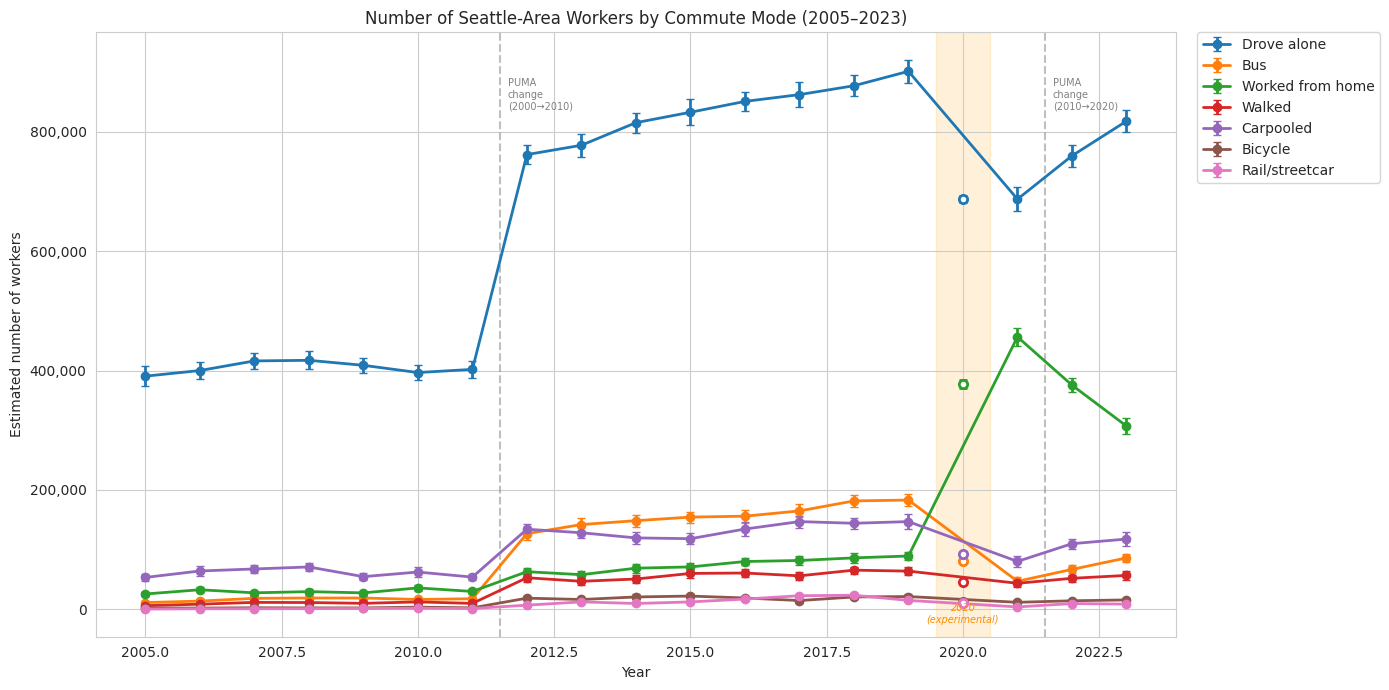

In [9]:
# Focus on the major modes
major_modes = ['Drove alone', 'Bus', 'Worked from home', 'Walked',
               'Carpooled', 'Bicycle', 'Rail/streetcar']


def add_puma_breaks_and_2020(ax):
    """Add PUMA geography break lines and 2020 experimental shading to a plot."""
    ymin, ymax = ax.get_ylim()

    # PUMA geography breaks
    for x, label in [(2011.5, 'PUMA\nchange\n(2000→2010)'),
                     (2021.5, 'PUMA\nchange\n(2010→2020)')]:
        ax.axvline(x=x, color='gray', linestyle='--', alpha=0.5)
        ax.text(x + 0.15, ymax * 0.92, label, fontsize=7, color='gray', va='top')

    # 2020 experimental estimate shading
    ax.axvspan(2019.5, 2020.5, alpha=0.15, color='orange', zorder=0)
    ax.text(2020, ymin + (ymax - ymin) * 0.02, '2020\n(experimental)',
            fontsize=7, color='darkorange', ha='center', va='bottom', style='italic')


fig, ax = plt.subplots(figsize=(14, 7))
for mode in major_modes:
    sub = mode_trends[mode_trends['mode'] == mode].sort_values('year')

    # Split 2020 from other years for distinct styling
    regular = sub[sub['year'] != 2020]
    exp_2020 = sub[sub['year'] == 2020]

    line = ax.errorbar(regular['year'], regular['n_weighted'],
                       yerr=1.96 * regular['n_weighted_se'],
                       marker='o', capsize=3, label=mode, linewidth=2)
    color = line[0].get_color()

    if len(exp_2020) > 0:
        ax.errorbar(exp_2020['year'], exp_2020['n_weighted'],
                    yerr=1.96 * exp_2020['n_weighted_se'],
                    marker='o', capsize=3, color=color, linewidth=2,
                    markerfacecolor='white', markeredgecolor=color, markeredgewidth=2)

ax.set_xlabel('Year')
ax.set_ylabel('Estimated number of workers')
ax.set_title('Number of Seattle-Area Workers by Commute Mode (2005–2023)')
ax.legend(loc='upper left', bbox_to_anchor=(1.02, 1), borderaxespad=0)
ax.yaxis.set_major_formatter(mtick.FuncFormatter(lambda x, _: f'{x:,.0f}'))

add_puma_breaks_and_2020(ax)

plt.tight_layout()
plt.show()

## Plot: Fraction of workers by commute mode over time

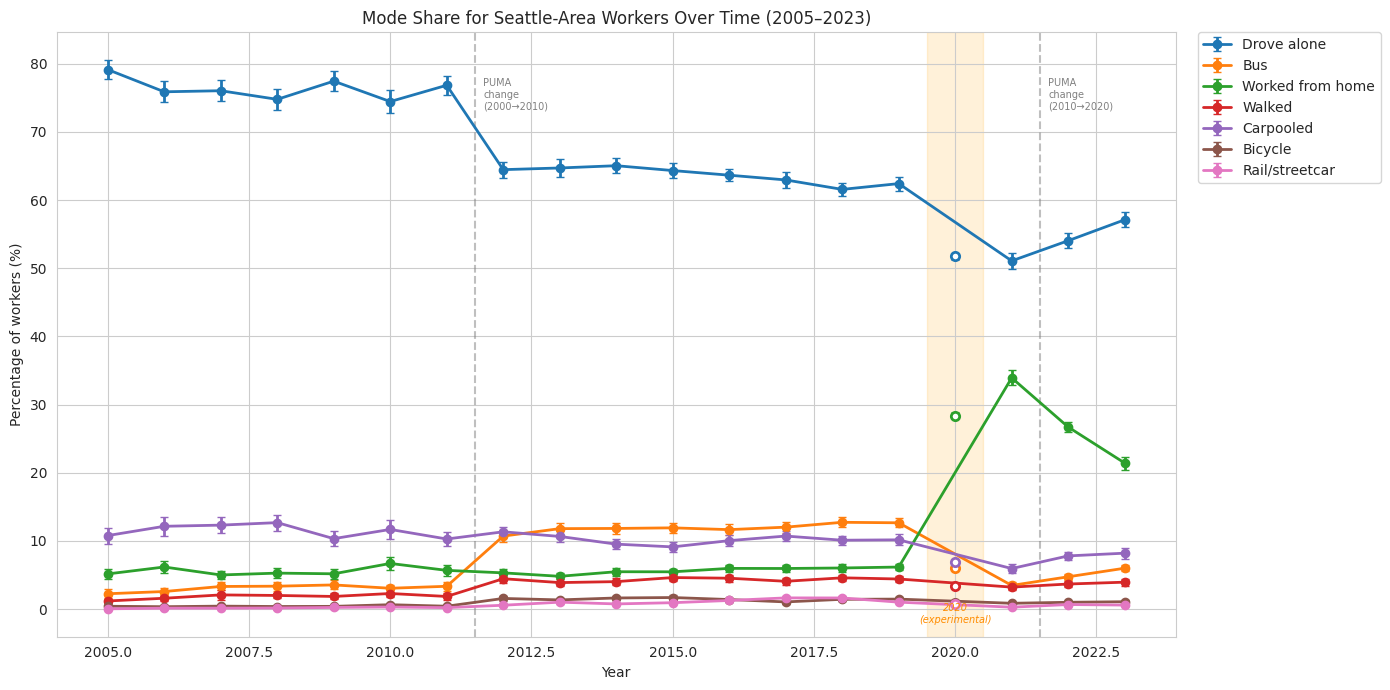

In [10]:
fig, ax = plt.subplots(figsize=(14, 7))
for mode in major_modes:
    sub = mode_trends[mode_trends['mode'] == mode].sort_values('year')

    regular = sub[sub['year'] != 2020]
    exp_2020 = sub[sub['year'] == 2020]

    line = ax.errorbar(regular['year'], 100 * regular['fraction'],
                       yerr=100 * 1.96 * regular['fraction_se'],
                       marker='o', capsize=3, label=mode, linewidth=2)
    color = line[0].get_color()

    if len(exp_2020) > 0:
        ax.errorbar(exp_2020['year'], 100 * exp_2020['fraction'],
                    yerr=100 * 1.96 * exp_2020['fraction_se'],
                    marker='o', capsize=3, color=color, linewidth=2,
                    markerfacecolor='white', markeredgecolor=color, markeredgewidth=2)

ax.set_xlabel('Year')
ax.set_ylabel('Percentage of workers (%)')
ax.set_title('Mode Share for Seattle-Area Workers Over Time (2005–2023)')
ax.legend(loc='upper left', bbox_to_anchor=(1.02, 1), borderaxespad=0)

add_puma_breaks_and_2020(ax)

plt.tight_layout()
plt.show()

## Compute travel time trends by mode

Mean travel time (JWMNP, in minutes) by commute mode and year, with SEs.

In [11]:
# Exclude worked-from-home (travel time not applicable)
# JWMNP may be stored as object/string in some years; coerce to numeric
all_workers['JWMNP'] = pd.to_numeric(all_workers['JWMNP'], errors='coerce')

commuters = all_workers[
    (all_workers['mode'] != 'Worked from home') &
    (all_workers['JWMNP'].notna()) &
    (all_workers['JWMNP'] > 0)
].copy()

time_trend_rows = []
commute_modes = ['Drove alone', 'Bus', 'Carpooled', 'Bicycle', 'Walked', 'Rail/streetcar', 'Ferry']

for year in sorted(commuters['YEAR'].unique()):
    yr_data = commuters[commuters['YEAR'] == year]

    for mode in commute_modes:
        sub = yr_data[yr_data['mode'] == mode]
        if len(sub) < 10:
            continue

        rep_df = sub[REP_COLS] if REP_COLS[0] in sub.columns else pd.DataFrame()
        if len(rep_df) > 0:
            mean_time, time_se = weighted_mean_with_se(
                sub['JWMNP'].values, sub['PWGTP'].values, rep_df
            )
        else:
            mean_time = np.average(sub['JWMNP'], weights=sub['PWGTP'])
            time_se = np.nan

        time_trend_rows.append({
            'year': year,
            'mode': mode,
            'mean_travel_time_min': mean_time,
            'travel_time_se': time_se,
            'n_records': len(sub),
        })

time_trends = pd.DataFrame(time_trend_rows)
print(f'Travel time trend table: {len(time_trends)} rows')
time_trends.head(10)

Travel time trend table: 124 rows


,year,mode,mean_travel_time_min,travel_time_se,n_records
0,2005,Drove alone,26.948436,0.432190,3614
1,2005,Bus,50.289320,4.382416,82
2,2005,Carpooled,32.075602,1.238505,507
3,2005,Bicycle,28.701155,7.038409,19
4,2005,Walked,9.837174,2.439420,55
5,2006,Drove alone,27.058579,0.371504,3784
6,2006,Bus,54.126874,4.815090,109
7,2006,Carpooled,35.505706,1.457543,561
8,2006,Bicycle,49.345416,12.876465,19
9,2006,Walked,10.078093,1.355700,75


## Plot: Mean travel time by commute mode over time

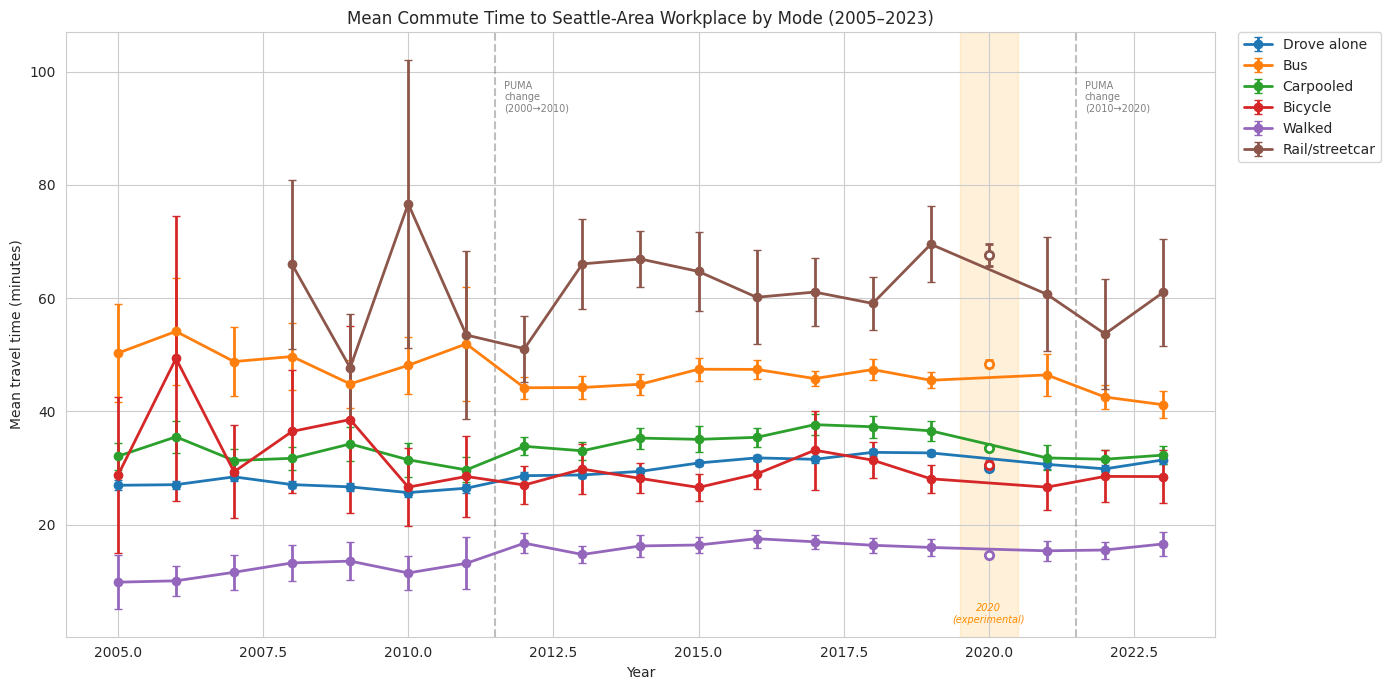

In [12]:
plot_modes = ['Drove alone', 'Bus', 'Carpooled', 'Bicycle', 'Walked', 'Rail/streetcar']

fig, ax = plt.subplots(figsize=(14, 7))
for mode in plot_modes:
    sub = time_trends[time_trends['mode'] == mode].sort_values('year')
    if len(sub) == 0:
        continue

    regular = sub[sub['year'] != 2020]
    exp_2020 = sub[sub['year'] == 2020]

    line = ax.errorbar(regular['year'], regular['mean_travel_time_min'],
                       yerr=1.96 * regular['travel_time_se'],
                       marker='o', capsize=3, label=mode, linewidth=2)
    color = line[0].get_color()

    if len(exp_2020) > 0:
        ax.errorbar(exp_2020['year'], exp_2020['mean_travel_time_min'],
                    yerr=1.96 * exp_2020['travel_time_se'],
                    marker='o', capsize=3, color=color, linewidth=2,
                    markerfacecolor='white', markeredgecolor=color, markeredgewidth=2)

ax.set_xlabel('Year')
ax.set_ylabel('Mean travel time (minutes)')
ax.set_title('Mean Commute Time to Seattle-Area Workplace by Mode (2005–2023)')
ax.legend(loc='upper left', bbox_to_anchor=(1.02, 1), borderaxespad=0)

add_puma_breaks_and_2020(ax)

plt.tight_layout()
plt.show()

## Summary table

Combined mode share and travel time summary for the most recent year.

In [13]:
latest_year = mode_trends['year'].max()

summary = mode_trends[mode_trends['year'] == latest_year][['mode', 'n_weighted', 'fraction']].copy()
summary = summary.sort_values('n_weighted', ascending=False)

# Merge travel time for latest year
tt_latest = time_trends[time_trends['year'] == latest_year][['mode', 'mean_travel_time_min']]
summary = summary.merge(tt_latest, on='mode', how='left')

summary['fraction_pct'] = (100 * summary['fraction']).round(1)
summary['n_weighted'] = summary['n_weighted'].round(0).astype(int)
summary['mean_travel_time_min'] = summary['mean_travel_time_min'].round(1)

print(f'\nSummary for {latest_year}:')
print(summary[['mode', 'n_weighted', 'fraction_pct', 'mean_travel_time_min']]
      .rename(columns={
          'mode': 'Mode',
          'n_weighted': 'Workers (est.)',
          'fraction_pct': 'Share (%)',
          'mean_travel_time_min': 'Avg. time (min)',
      }).to_string(index=False))


Summary for 2023:
            Mode  Workers (est.)  Share (%)  Avg. time (min)
     Drove alone          818062       57.1             31.4
Worked from home          306910       21.4              NaN
       Carpooled          117567        8.2             32.3
             Bus           85958        6.0             41.2
          Walked           56626        4.0             16.6
           Other           16465        1.1              NaN
         Bicycle           15557        1.1             28.5
  Rail/streetcar            8503        0.6             61.0
           Ferry            6976        0.5             86.3
